# Audio Classification with an RNN

This notebook builds a sequence-based audio classifier using MFCC features and a PyTorch RNN (stacked LSTM).

The default setup below uses the cleaned ESC50 dataset, which is the most convenient single-label multi-class starting point. The FSD50K path variables are included as ready-to-edit placeholders if you want to switch datasets later.

## 1. Environment Setup & Data Loading

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# Optional: install packages if your Colab runtime is missing anything.
# !pip install -q librosa seaborn

import os
import random

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, Dataset

# Keep runs as repeatable as Colab allows.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Use GPU if it is available.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

COLAB_ROOT = '/content/drive/MyDrive/ResoNET'
DATA_DIR = os.path.join(COLAB_ROOT, 'Data')

# Cleaned metadata CSVs.
ESC50_CSV_PATH = os.path.join(DATA_DIR, 'Cleaned_ESC50.csv')
ESC50_AUDIO_DIR = os.path.join(DATA_DIR, 'ESC50_16000')

# FSD50K files already in this repo.
FSD50K_DEV_CSV_PATH = os.path.join(DATA_DIR, 'FSD50K_dev_cleaned.csv')
FSD50K_EVAL_CSV_PATH = os.path.join(DATA_DIR, 'FSDK50_eval_cleaned.csv')
FSD50K_DEV_AUDIO_DIR = os.path.join(DATA_DIR, 'FSD50K.dev_audio_16k')
FSD50K_EVAL_AUDIO_DIR = os.path.join(DATA_DIR, 'FSD50K.eval_audio_16k')

# Kept here for quick swapping later.
TRAIN_AUDIO_DIR = ESC50_AUDIO_DIR
VAL_AUDIO_DIR = ESC50_AUDIO_DIR
TEST_AUDIO_DIR = ESC50_AUDIO_DIR

print('Drive root:', COLAB_ROOT)
print('Data directory exists:', os.path.exists(DATA_DIR))
print('ESC50 CSV exists:', os.path.exists(ESC50_CSV_PATH))
print('ESC50 audio directory exists:', os.path.exists(ESC50_AUDIO_DIR))
print('FSD50K dev CSV exists:', os.path.exists(FSD50K_DEV_CSV_PATH))
print('FSD50K eval CSV exists:', os.path.exists(FSD50K_EVAL_CSV_PATH))
print('FSD50K dev audio directory exists:', os.path.exists(FSD50K_DEV_AUDIO_DIR))
print('FSD50K eval audio directory exists:', os.path.exists(FSD50K_EVAL_AUDIO_DIR))

Using device: cuda
Drive root: /content/drive/MyDrive
Data directory exists: True
ESC50 CSV exists: True
ESC50 audio directory exists: True
FSD50K dev CSV exists: True
FSD50K eval CSV exists: True
FSD50K dev audio directory exists: True
FSD50K eval audio directory exists: True


## 2. Data Preprocessing (Sequential Features)

The key idea here is to keep the audio as a sequence, not as a single static image. Each file is converted into an MFCC time series with shape `(time_steps, features)`, which is a natural input format for an RNN.

In [7]:
# Audio / feature extraction settings.
SAMPLE_RATE = 16000
N_MFCC = 40
N_FFT = 1024
HOP_LENGTH = 512
MAX_TIME_STEPS = 160
TEST_SIZE = 0.15
VAL_SIZE = 0.15
BATCH_SIZE = 32
NUM_EPOCHS = 40
LEARNING_RATE = 1e-3


def build_audio_path(audio_dir, file_name):
    """Create an absolute WAV path from a CSV filename entry."""
    file_name = str(file_name).strip()
    if not file_name.lower().endswith('.wav'):
        file_name = f'{file_name}.wav'
    return os.path.join(audio_dir, file_name)



def load_metadata(csv_path, audio_dir, file_column='fname', label_column='labels', dataset_name='dataset'):
    """Load a cleaned metadata CSV and attach fully qualified audio paths."""
    df = pd.read_csv(csv_path).copy()
    df['audio_path'] = df[file_column].apply(lambda value: build_audio_path(audio_dir, value))
    df['label'] = df[label_column].astype(str).str.strip().str.lower()
    df['source'] = dataset_name
    df = df[df['audio_path'].apply(os.path.exists)].reset_index(drop=True)
    return df[['audio_path', 'label', 'source']]



def load_combined_metadata():
    """Load ESC50 and FSD50K metadata into one combined dataframe."""
    dataset_specs = [
        ('ESC50', ESC50_CSV_PATH, ESC50_AUDIO_DIR),
        ('FSD50K-dev', FSD50K_DEV_CSV_PATH, FSD50K_DEV_AUDIO_DIR),
        ('FSD50K-eval', FSD50K_EVAL_CSV_PATH, FSD50K_EVAL_AUDIO_DIR),
    ]

    frames = []
    for dataset_name, csv_path, audio_dir in dataset_specs:
        if not os.path.exists(csv_path):
            print(f'Skipping missing CSV: {csv_path}')
            continue

        frame = load_metadata(csv_path, audio_dir, dataset_name=dataset_name)
        frames.append(frame)
        print(f'{dataset_name}: {len(frame)} usable audio files')

    if not frames:
        raise FileNotFoundError('No cleaned metadata CSV files were found.')

    return pd.concat(frames, ignore_index=True)



def load_audio(audio_path, sample_rate=SAMPLE_RATE):
    """Load an audio file with librosa and return a mono waveform."""
    waveform, _ = librosa.load(audio_path, sr=sample_rate, mono=True)
    return waveform



def extract_mfcc_sequence(audio_path, sample_rate=SAMPLE_RATE, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH, max_time_steps=MAX_TIME_STEPS):
    """Convert one audio clip into a fixed-length MFCC sequence.

    Output shape: (time_steps, features)
    """
    waveform = load_audio(audio_path, sample_rate=sample_rate)
    if waveform.size == 0:
        return None

    mfcc = librosa.feature.mfcc(y=waveform, sr=sample_rate, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length)
    mfcc = mfcc.T  # librosa returns (features, time); transpose to (time, features).

    if mfcc.shape[0] < max_time_steps:
        pad_amount = max_time_steps - mfcc.shape[0]
        mfcc = np.pad(mfcc, pad_width=((0, pad_amount), (0, 0)), mode='constant')
    else:
        mfcc = mfcc[:max_time_steps, :]

    return mfcc.astype(np.float32)



def compute_feature_stats(df):
    """Compute training-set mean and std for per-feature MFCC normalization."""
    feature_sum = np.zeros(N_MFCC, dtype=np.float64)
    feature_sq_sum = np.zeros(N_MFCC, dtype=np.float64)
    frame_count = 0
    skipped_files = 0

    for audio_path in df['audio_path']:
        mfcc_sequence = extract_mfcc_sequence(audio_path)
        if mfcc_sequence is None:
            skipped_files += 1
            continue

        feature_sum += mfcc_sequence.sum(axis=0)
        feature_sq_sum += np.square(mfcc_sequence).sum(axis=0)
        frame_count += mfcc_sequence.shape[0]

    if frame_count == 0:
        raise ValueError('Could not compute feature statistics because no audio files were readable.')

    mean = feature_sum / frame_count
    variance = feature_sq_sum / frame_count - np.square(mean)
    std = np.sqrt(np.maximum(variance, 1e-8))

    if skipped_files:
        print(f'Skipped {skipped_files} files while computing normalization statistics.')

    return mean.astype(np.float32), std.astype(np.float32)


class AudioDataset(Dataset):
    """Lazy-loading audio dataset that returns normalized MFCC sequences and encoded labels."""

    def __init__(self, dataframe, feature_mean=None, feature_std=None):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.audio_paths = self.dataframe['audio_path'].tolist()
        self.labels = self.dataframe['label_id'].tolist()
        self.feature_mean = None if feature_mean is None else np.asarray(feature_mean, dtype=np.float32).reshape(1, -1)
        self.feature_std = None if feature_std is None else np.asarray(feature_std, dtype=np.float32).reshape(1, -1)

    def __len__(self):
        return len(self.audio_paths)

    def __getitem__(self, idx):
        audio_path = self.audio_paths[idx]
        label_id = self.labels[idx]

        mfcc_sequence = extract_mfcc_sequence(audio_path)
        if mfcc_sequence is None:
            raise RuntimeError(f'Could not load audio file: {audio_path}')

        if self.feature_mean is not None and self.feature_std is not None:
            mfcc_sequence = (mfcc_sequence - self.feature_mean) / self.feature_std

        sequence_tensor = torch.tensor(mfcc_sequence, dtype=torch.float32)
        label_tensor = torch.tensor(label_id, dtype=torch.long)
        return sequence_tensor, label_tensor


# Load the cleaned metadata from ESC50 plus both FSD50K CSVs.
metadata = load_combined_metadata()
print('Loaded samples across all datasets:', len(metadata))
print(metadata['source'].value_counts())
print('Unique labels after normalization:', metadata['label'].nunique())

# Encode labels using sklearn's LabelEncoder.
label_encoder = LabelEncoder()
metadata['label_id'] = label_encoder.fit_transform(metadata['label'])
num_classes = len(label_encoder.classes_)

# Split into train, validation, and test sets.
train_df, val_df, test_df = safe_train_val_test_split(metadata)
print('Train / Val / Test sizes:', len(train_df), len(val_df), len(test_df))

# Normalize using only the training set.
feature_mean, feature_std = compute_feature_stats(train_df)

# Build lazy audio datasets for each split.
train_dataset = AudioDataset(train_df, feature_mean=feature_mean, feature_std=feature_std)
val_dataset = AudioDataset(val_df, feature_mean=feature_mean, feature_std=feature_std)
test_dataset = AudioDataset(test_df, feature_mean=feature_mean, feature_std=feature_std)

# Wrap the datasets in DataLoaders for batching and shuffling.
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# The sequence length stays fixed because MFCCs are padded or truncated.
INPUT_SHAPE = (MAX_TIME_STEPS, N_MFCC)

print('Input sequence shape:', INPUT_SHAPE)
print('Number of classes:', num_classes)
print('Example dataset length:', len(train_dataset))

ESC50: 200 usable audio files
FSD50K-dev: 2253 usable audio files
FSD50K-eval: 1004 usable audio files
Loaded samples across all datasets: 3457
source
FSD50K-dev     2253
FSD50K-eval    1004
ESC50           200
Name: count, dtype: int64
Unique labels after normalization: 7
Train / Val / Test sizes: 2419 519 519
Input sequence shape: (160, 40)
Number of classes: 7
Example dataset length: 2419


## 3. Model Architecture (RNN)

The model below uses a stacked PyTorch LSTM architecture. The first recurrent layer keeps the full sequence so the next recurrent layer can process it. The final recurrent layer produces a compact hidden representation that is passed to a linear softmax-style classifier.

In [8]:
class AudioRNNClassifier(nn.Module):
    def __init__(self, input_size, hidden_size_1, hidden_size_2, num_classes, dropout_rate=0.3):
        super().__init__()
        self.lstm_1 = nn.LSTM(input_size=input_size, hidden_size=hidden_size_1, batch_first=True)
        self.dropout_1 = nn.Dropout(dropout_rate)
        self.lstm_2 = nn.LSTM(input_size=hidden_size_1, hidden_size=hidden_size_2, batch_first=True)
        self.dropout_2 = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(hidden_size_2, num_classes)

    def forward(self, x):
        # Let the first LSTM read the full sequence.
        x, _ = self.lstm_1(x)
        x = self.dropout_1(x)
        # The second LSTM compresses the temporal pattern.
        x, _ = self.lstm_2(x)
        x = x[:, -1, :]
        x = self.dropout_2(x)
        # Return raw class scores; CrossEntropyLoss handles the softmax part.
        logits = self.classifier(x)
        return logits


model = AudioRNNClassifier(
    input_size=INPUT_SHAPE[1],
    hidden_size_1=128,
    hidden_size_2=64,
    num_classes=num_classes,
    dropout_rate=0.3,
).to(device)

print(model)

AudioRNNClassifier(
  (lstm_1): LSTM(40, 128, batch_first=True)
  (dropout_1): Dropout(p=0.3, inplace=False)
  (lstm_2): LSTM(128, 64, batch_first=True)
  (dropout_2): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=64, out_features=7, bias=True)
)


## 4. Training Loop

Early stopping restores the best weights when validation loss stops improving, and ReduceLROnPlateau lowers the learning rate when training plateaus.

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
)


def run_epoch(model, loader, criterion, optimizer=None):
    """Run one training or evaluation epoch and return loss plus accuracy."""
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for batch_inputs, batch_labels in loader:
        batch_inputs = batch_inputs.to(device)
        batch_labels = batch_labels.to(device)

        if is_training:
            # Clear old gradients before the next update.
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            logits = model(batch_inputs)
            loss = criterion(logits, batch_labels)

            if is_training:
                loss.backward()
                optimizer.step()

        batch_size = batch_labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == batch_labels).sum().item()
        total_samples += batch_size

    average_loss = total_loss / total_samples
    average_accuracy = total_correct / total_samples
    return average_loss, average_accuracy


history = {
    'train_loss': [],
    'val_loss': [],
    'train_accuracy': [],
    'val_accuracy': [],
}

best_val_loss = float('inf')
best_state_dict = None
patience = 8
patience_counter = 0

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_accuracy = run_epoch(model, train_loader, criterion, optimizer=optimizer)
    val_loss, val_accuracy = run_epoch(model, val_loader, criterion)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_accuracy'].append(train_accuracy)
    history['val_accuracy'].append(val_accuracy)

    current_lr = optimizer.param_groups[0]['lr']
    print(
        f'Epoch {epoch:02d} | '
        f'train_loss={train_loss:.4f} | train_acc={train_accuracy:.4f} | '
        f'val_loss={val_loss:.4f} | val_acc={val_accuracy:.4f} | lr={current_lr:.2e}'
    )

    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        best_state_dict = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'Early stopping triggered at epoch {epoch}.')
            break

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

model = model.to(device)

Epoch 01 | train_loss=1.1271 | train_acc=0.4816 | val_loss=0.9782 | val_acc=0.4855 | lr=1.00e-03
Epoch 02 | train_loss=0.9809 | train_acc=0.4783 | val_loss=0.9573 | val_acc=0.5723 | lr=1.00e-03
Epoch 03 | train_loss=0.9580 | train_acc=0.5333 | val_loss=0.9461 | val_acc=0.4817 | lr=1.00e-03
Epoch 04 | train_loss=0.9507 | train_acc=0.5469 | val_loss=0.9055 | val_acc=0.6031 | lr=1.00e-03
Epoch 05 | train_loss=0.9220 | train_acc=0.5746 | val_loss=0.8886 | val_acc=0.5954 | lr=1.00e-03
Epoch 06 | train_loss=0.8869 | train_acc=0.5754 | val_loss=0.8228 | val_acc=0.6050 | lr=1.00e-03
Epoch 07 | train_loss=0.7872 | train_acc=0.5998 | val_loss=0.7507 | val_acc=0.5511 | lr=1.00e-03
Epoch 08 | train_loss=0.7366 | train_acc=0.6077 | val_loss=0.7171 | val_acc=0.6358 | lr=1.00e-03
Epoch 09 | train_loss=0.7021 | train_acc=0.6507 | val_loss=0.6921 | val_acc=0.6667 | lr=1.00e-03
Epoch 10 | train_loss=0.6425 | train_acc=0.6920 | val_loss=0.6840 | val_acc=0.6879 | lr=1.00e-03
Epoch 11 | train_loss=0.6149 |

## 5. Evaluation & Visualization

This final section plots the learning curves, evaluates the model on the held-out test set, and prints a classification report plus a confusion matrix.

Test loss: 0.6162
Test accuracy: 0.7303


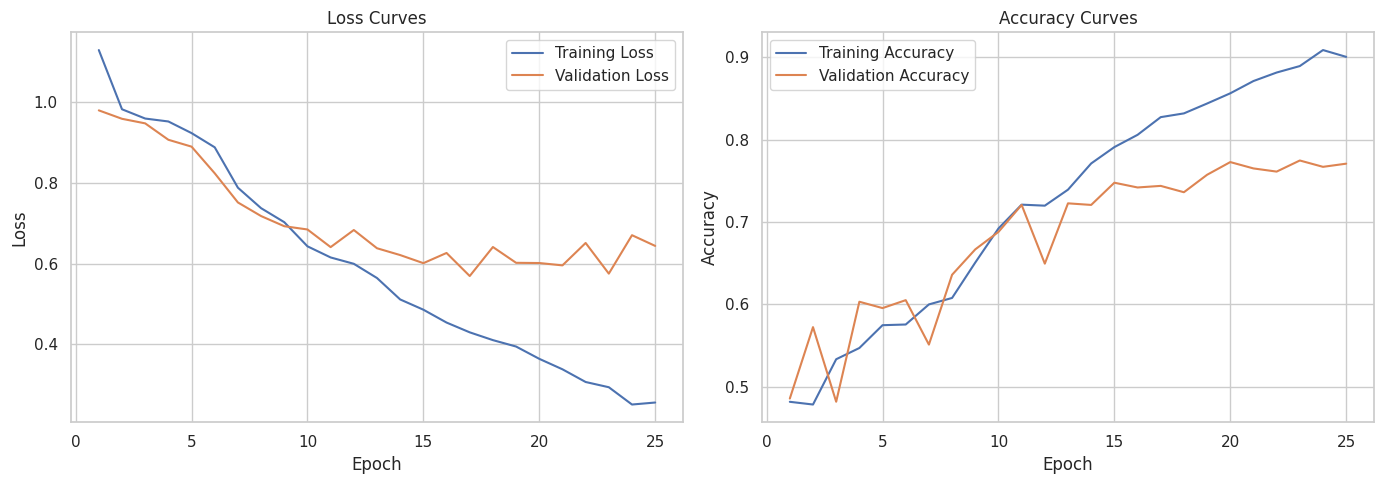

Classification Report:
                 precision    recall  f1-score   support

          alarm       0.80      0.64      0.71       237
   church_bells       0.55      1.00      0.71         6
    clock_alarm       0.33      0.17      0.22         6
door_wood_knock       0.46      1.00      0.63         6
       doorbell       0.71      0.84      0.77       252
 glass_breaking       0.20      0.17      0.18         6
          siren       1.00      0.17      0.29         6

       accuracy                           0.73       519
      macro avg       0.58      0.57      0.50       519
   weighted avg       0.74      0.73      0.72       519



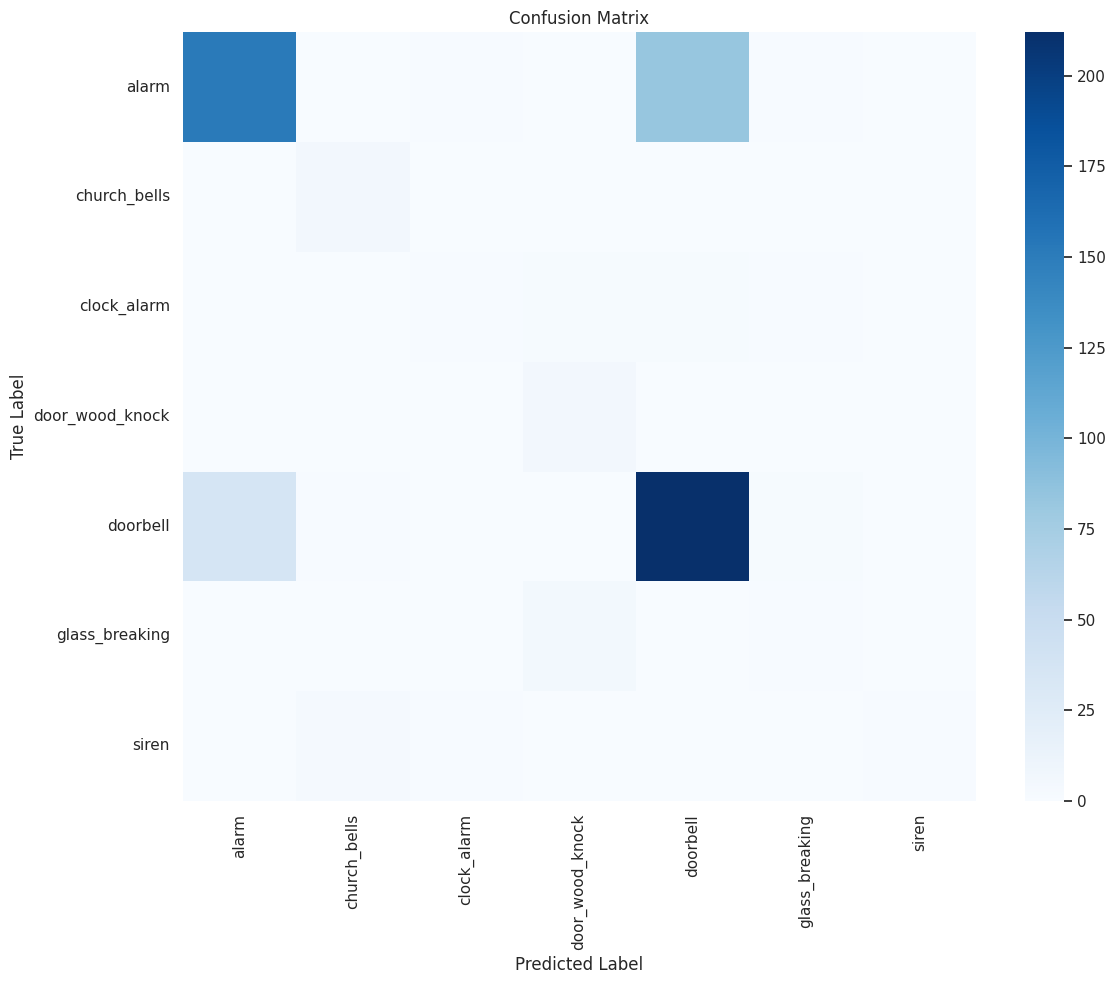

In [10]:
def evaluate_loader(model, loader, criterion):
    """Evaluate a model on a loader and return loss, accuracy, and predictions."""
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for batch_inputs, batch_labels in loader:
            batch_inputs = batch_inputs.to(device)
            batch_labels = batch_labels.to(device)

            logits = model(batch_inputs)
            loss = criterion(logits, batch_labels)
            predictions = logits.argmax(dim=1)

            batch_size = batch_labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (predictions == batch_labels).sum().item()
            total_samples += batch_size

            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(batch_labels.cpu().numpy())

    average_loss = total_loss / total_samples
    average_accuracy = total_correct / total_samples
    y_pred = np.concatenate(all_predictions)
    y_true = np.concatenate(all_targets)
    return average_loss, average_accuracy, y_true, y_pred


# Evaluate on the test split.
test_loss, test_accuracy, y_true, y_pred = evaluate_loader(model, test_loader, criterion)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_accuracy:.4f}')

# Plot training history.
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(history['train_loss']) + 1)
axes[0].plot(epochs, history['train_loss'], label='Training Loss')
axes[0].plot(epochs, history['val_loss'], label='Validation Loss')
axes[0].set_title('Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(epochs, history['train_accuracy'], label='Training Accuracy')
axes[1].plot(epochs, history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Accuracy Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Classification Report:')
print(classification_report(y_true, y_pred, labels=np.arange(num_classes), target_names=label_encoder.classes_, zero_division=0))

# Confusion matrix.
cm = confusion_matrix(y_true, y_pred, labels=np.arange(num_classes))
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()